<h1>RESPON MODUL 2

<h3>IMPORT LIBRARY

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<h3>MEMBUAT FUNGSI RGB & GRAYSCALE

In [2]:
def rgb(img) :
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def gray(img) :
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

<h3>MEMBUAT DATASET MANUAL

In [ ]:
ri1 = {
    'nama': "Soekarno",
    'img': rgb(cv2.imread('Assets/Soekarno.jpg')),
    'gray': gray(cv2.imread('Assets/Soekarno.jpg')),
    'waktu': 22
}
ri2 = {
    'nama': "Soeharto",
    'img': rgb(cv2.imread('Assets/Soeharto.jpg')),
    'gray': gray(cv2.imread('Assets/Soeharto.jpg')),
    'waktu': 32
}
ri3 = {
    'nama': "B.J. Habibie",
    'img': rgb(cv2.imread('Assets/B.J. Habibie.jpg')),
    'gray': gray(cv2.imread('Assets/B.J. Habibie.jpg')),
    'waktu': 1
}
ri4 = {
    'nama': "Abdurahman Wahid",
    'img': rgb(cv2.imread('Assets/Abdurahman Wahid.jpg')),
    'gray': gray(cv2.imread('Assets/Abdurahman Wahid.jpg')),
    'waktu': 2
}
ri5 = {
    'nama': "Megawati Soekarnoputri",
    'img': rgb(cv2.imread('Assets/Megawati Soekarnoputri.jpg')),
    'gray': gray(cv2.imread('Assets/Megawati Soekarnoputri.jpg')),
    'waktu': 3
}
ri6 = {
    'nama': "Susilo Bambang Yudhoyono",
    'img': rgb(cv2.imread('Assets/Susilo Bambang Yudhoyono.jpg')),
    'gray': gray(cv2.imread('Assets/Susilo Bambang Yudhoyono.jpg')),
    'waktu': 10
}
ri7 = {
    'nama': "Joko Widodo",
    'img': rgb(cv2.imread('Assets/Joko Widodo.jpg')),
    'gray': gray(cv2.imread('Assets/Joko Widodo.jpg')),
    'waktu': 10
}
ri8 = {
    'nama': "Prabowo Subianto",
    'img': rgb(cv2.imread('Assets/Prabowo Subianto.jpg')),
    'gray': gray(cv2.imread('Assets/Prabowo Subianto.jpg')),
    'waktu': 2
}

dataset = [ri1, ri2, ri3, ri4, ri5, ri6, ri7, ri8]

<h3>MENAMPILKAN GAMBAR RGB

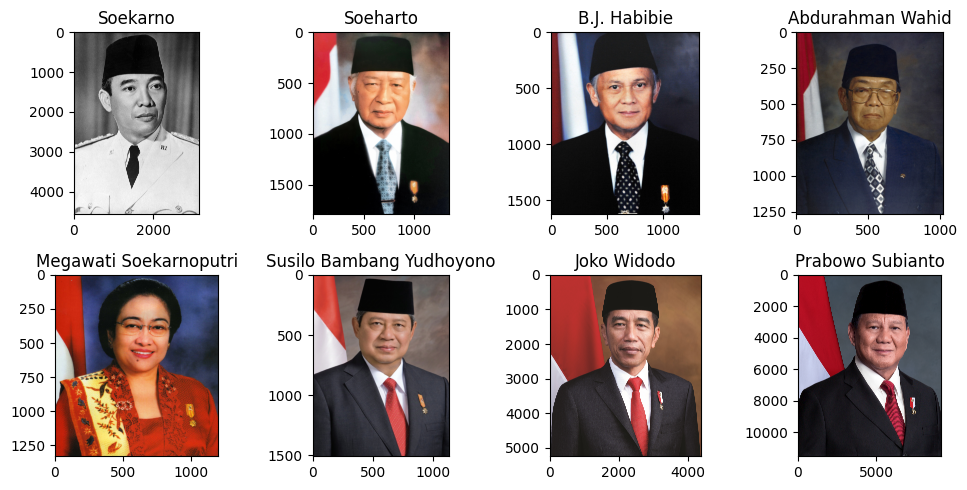

In [4]:
plt.figure(figsize=(10,5))

plt.subplot(2,4,1)
plt.imshow(dataset[0]['img'])
plt.title(dataset[0]['nama'])

plt.subplot(2,4,2)
plt.imshow(dataset[1]['img'])
plt.title(dataset[1]['nama'])

plt.subplot(2,4,3)
plt.imshow(dataset[2]['img'])
plt.title(dataset[2]['nama'])

plt.subplot(2,4,4)
plt.imshow(dataset[3]['img'])
plt.title(dataset[3]['nama'])

plt.subplot(2,4,5)
plt.imshow(dataset[4]['img'])
plt.title(dataset[4]['nama'])

plt.subplot(2,4,6)
plt.imshow(dataset[5]['img'])
plt.title(dataset[5]['nama'])

plt.subplot(2,4,7)
plt.imshow(dataset[6]['img'])
plt.title(dataset[6]['nama'])

plt.subplot(2,4,8)
plt.imshow(dataset[7]['img'])
plt.title(dataset[7]['nama'])

plt.tight_layout()
plt.show()

<h3>FUNGSI EKUALISASI

In [5]:
def ekualisasi(citra):
    height, width = citra.shape

    # histogram
    hist = np.zeros(256, dtype=int)

    for y in range(height):
        for x in range(width):
            nilai_pixel = citra[y, x]
            hist[nilai_pixel] += 1

    # CDF
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    # normalisasi
    cdf_normal = np.round(
        cdf * 255 / (height * width)
    ).astype(np.uint8)

    # hasil ekualisasi
    hasil = np.zeros_like(citra, dtype=np.uint8)

    for y in range(height):
        for x in range(width):
            hasil[y, x] = cdf_normal[citra[y, x]]

    return hasil

<H3>FUNGSI SPESIFIKASI

In [6]:
def spesifikasi(citra_asal, citra_target):

    # ukuran citra
    height_asal, width_asal = citra_asal.shape[:2]
    height_target, width_target = citra_target.shape[:2]

    # histogram
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    # hitung histogram citra asal
    for y in range(height_asal):
        for x in range(width_asal):
            nilai = citra_asal[y, x]
            hist_asal[nilai] += 1

    # hitung histogram citra target
    for y in range(height_target):
        for x in range(width_target):
            nilai = citra_target[y, x]
            hist_target[nilai] += 1

    # CDF
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    # hitung cumulative distribution function
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    # normalisasi CDF
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    # mapping histogram
    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):

        selisih_min = abs(cdf_asal[i] - cdf_target[0])
        indeks_terbaik = 0

        for j in range(1, 256):

            selisih = abs(cdf_asal[i] - cdf_target[j])

            if selisih < selisih_min:
                selisih_min = selisih
                indeks_terbaik = j

        map_hist[i] = indeks_terbaik

    # hasil akhir
    hasil = np.zeros((height_asal, width_asal), dtype=np.uint8)

    for y in range(height_asal):
        for x in range(width_asal):
            hasil[y, x] = map_hist[citra_asal[y, x]]

    return hasil

<H3>FUNGSI HISTOGRAM & VISUALISASI

In [7]:
def buat_hist(citra):
    histogram = [0] * 256

    height = len(citra)
    width = len(citra[0]) if height > 0 else 0

    for i in range(height):
        for j in range(width):
            val = int(citra[i][j])
            histogram[val] += 1

    return histogram

def plot_histogram(histogram, title):
    plt.figure(figsize=(10, 5))
    plt.bar(range(256), histogram, color='blue', alpha=0.7)
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel')
    plt.title(title)
    plt.xlim(0, 255)
    plt.grid(axis='y', alpha=0.75)
    plt.show()

def plot_dua_histogram(hist1, hist2, title, label1='Sebelum Ekualisasi', label2='Sesudah Ekualisasi', color1='green', color2='red'):

    plt.figure(figsize=(12, 6))

    plt.bar(range(256), hist1, color=color1, alpha=0.6, width=0.8, label=label1)

    plt.bar( range(256), hist2, color=color2, alpha=0.5, width=0.8, label=label2)

    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.title(title)

    plt.legend()
    plt.show()

<h3>EKUALISASI CITRA

In [8]:
for data in dataset:
    data['ekualisasi'] = ekualisasi(data['gray'])

<h3>MENAMPILKAN HISTOGRAM PERBANDINGAN SEBELUM & SESUDAH EKUALISASI

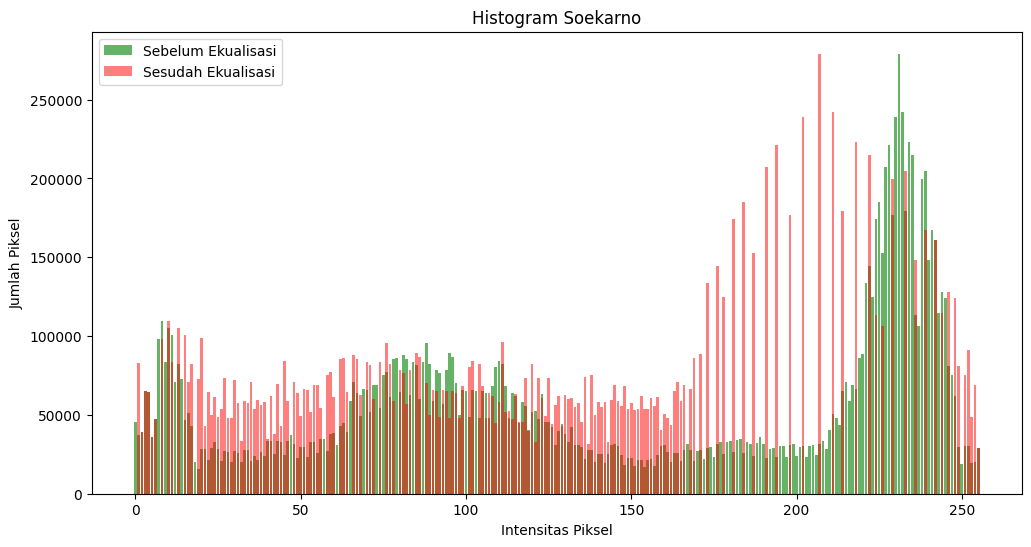

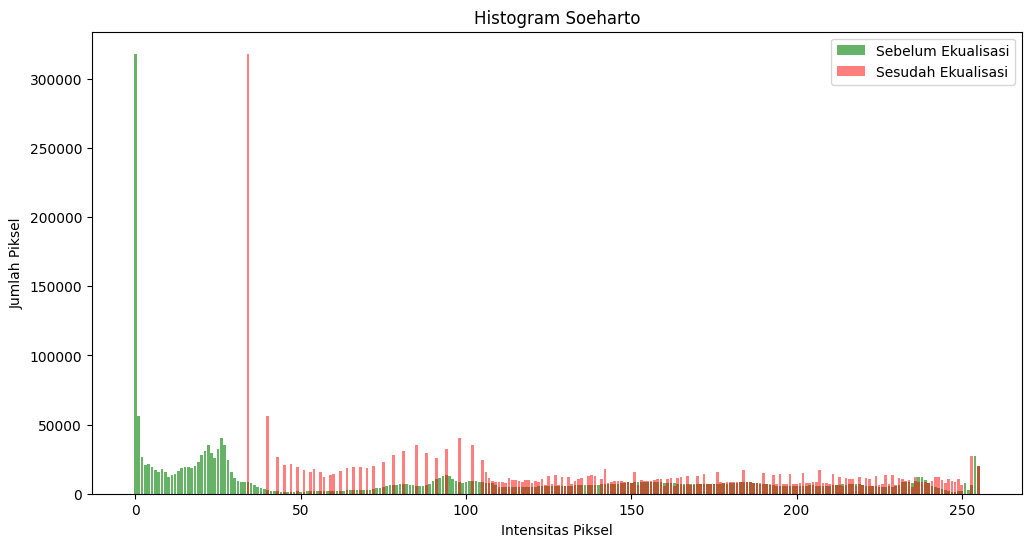

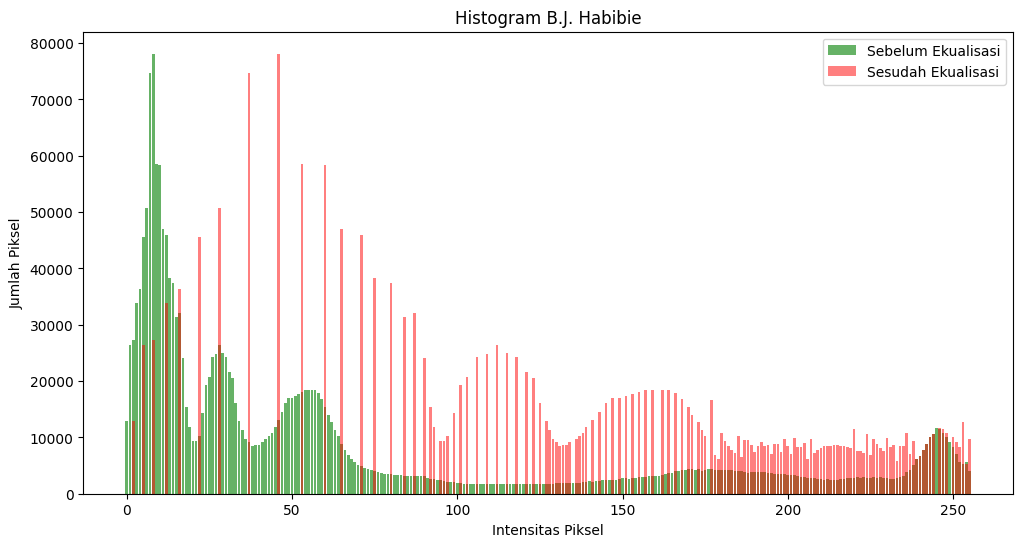

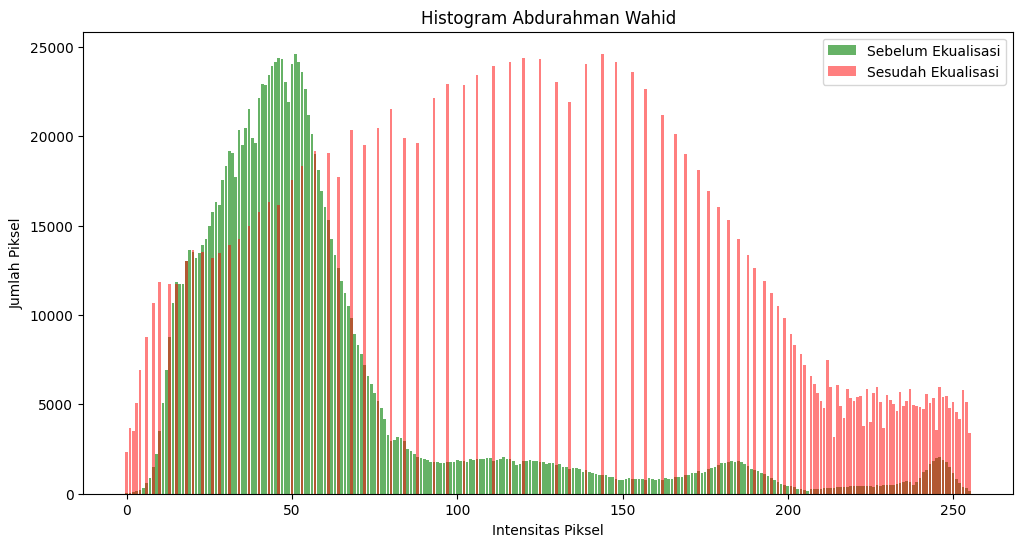

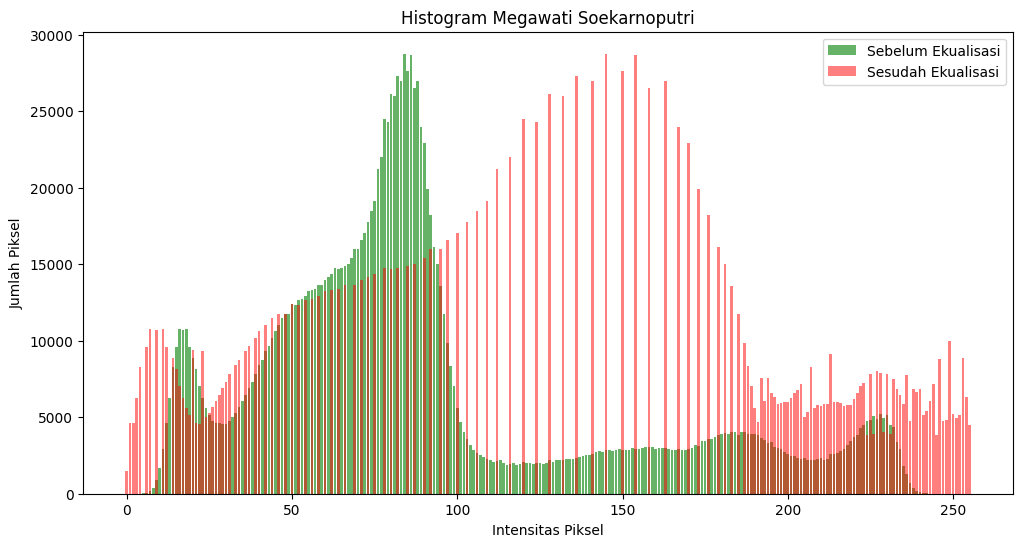

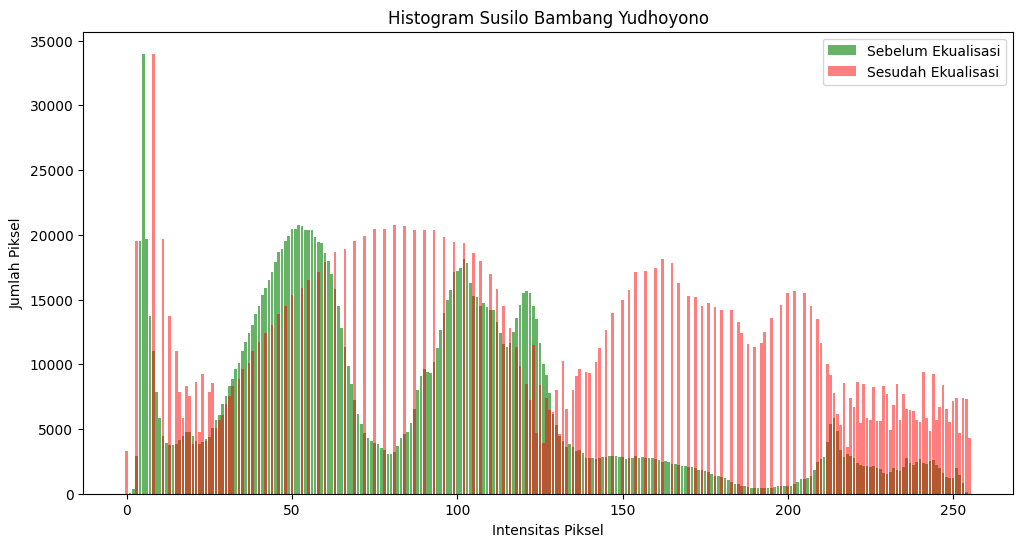

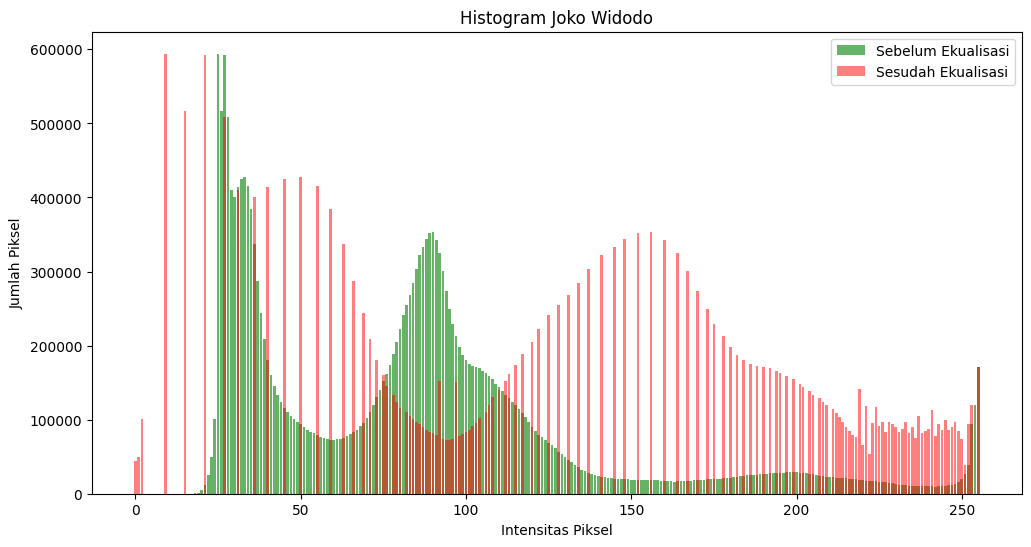

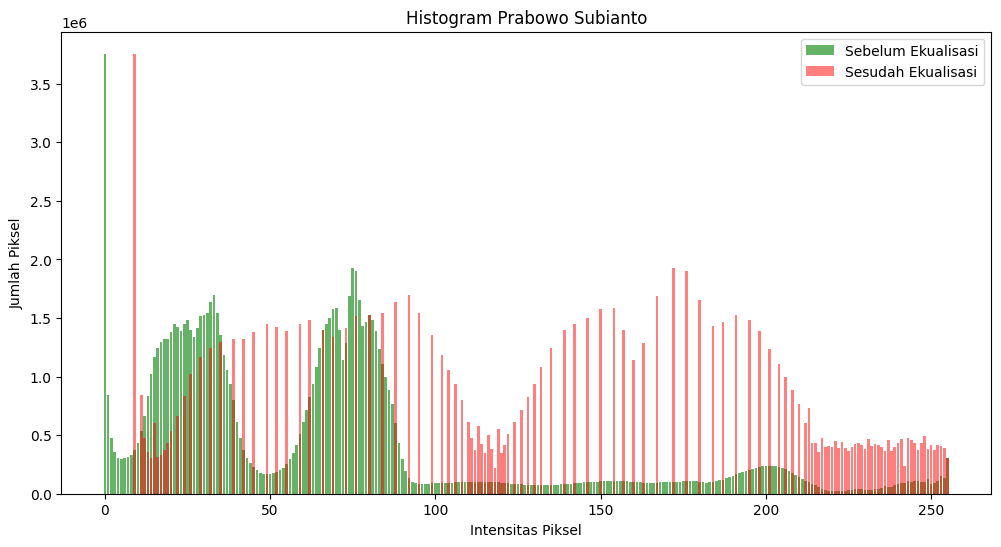

In [9]:
for data in dataset:

    plot_dua_histogram(
        buat_hist(data['gray']),
        buat_hist(data['ekualisasi']),
        f"Histogram {data['nama']}"
    )

<h3>SPESIFIKASI CITRA

In [10]:
langit = gray(cv2.imread('Assets/Langit.png'))
bunga = gray(cv2.imread('Assets/Bunga.png'))

for data in dataset:

    if data['waktu'] >= 10:

        data['target'] = 'Langit'

        data['spesifikasi'] = spesifikasi(
            data['gray'],
            langit
        )

    else:

        data['target'] = 'Bunga'

        data['spesifikasi'] = spesifikasi(
            data['gray'],
            bunga
        )

<h3>MENAMPILKAN HASIL SPESIFIKASI

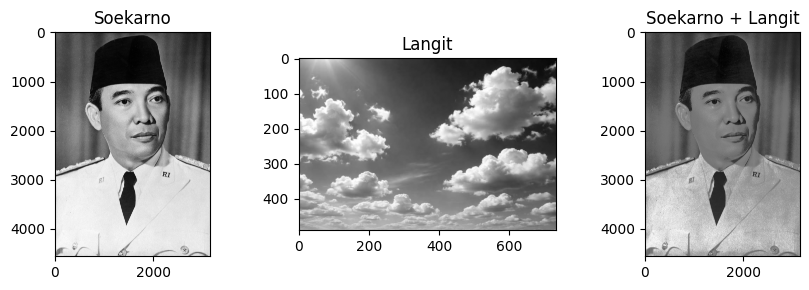

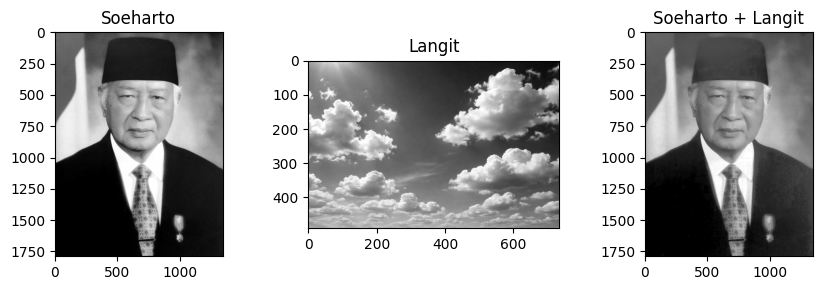

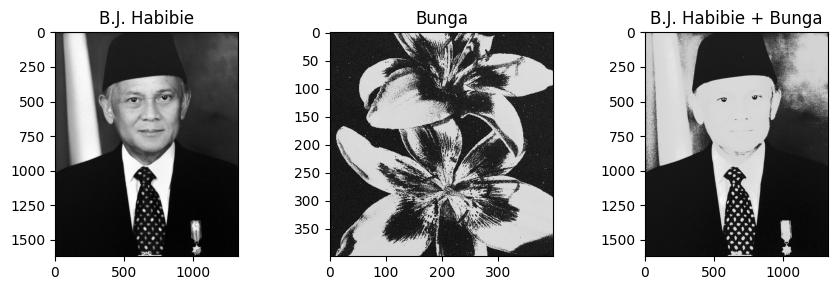

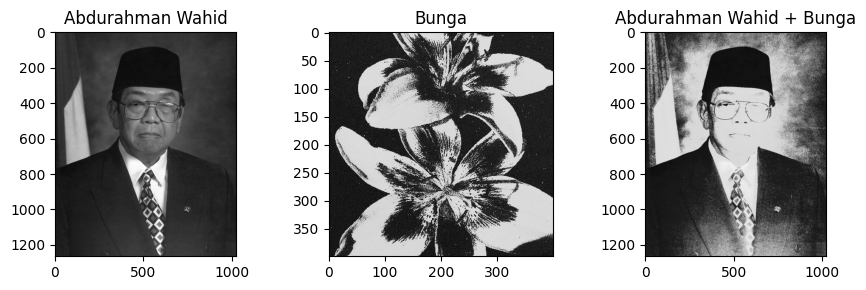

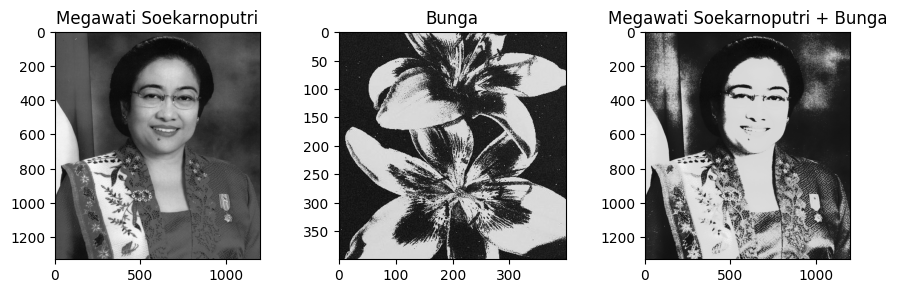

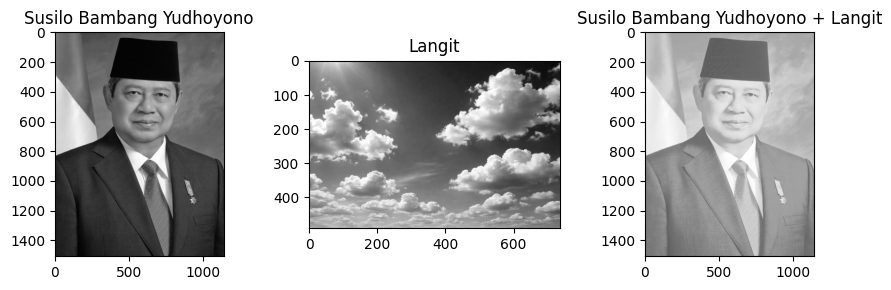

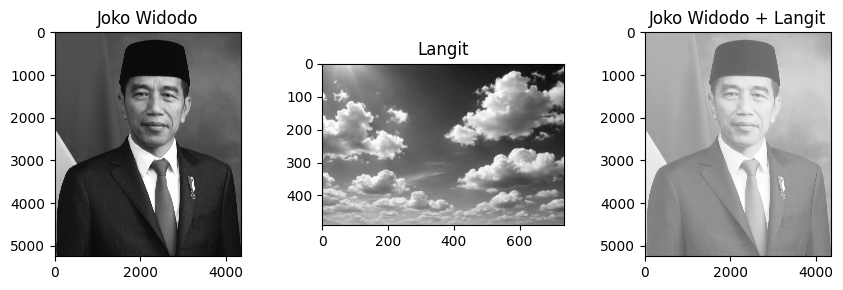

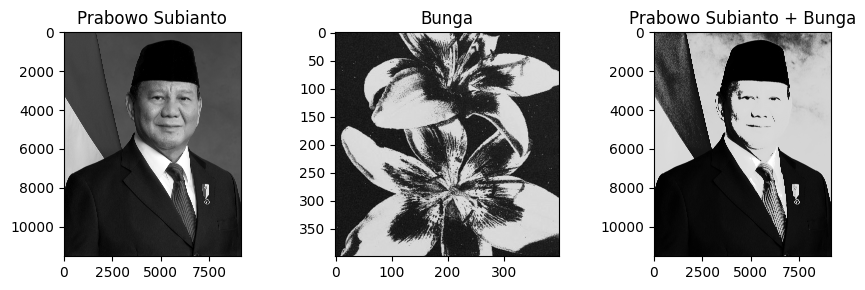

In [12]:
for data in dataset:

    plt.figure(figsize=(9,3))

    plt.subplot(1,3,1)
    plt.imshow(data['gray'], cmap='gray')
    plt.title(data['nama'])

    plt.subplot(1,3,2)

    if data['target'] == 'Langit':
        plt.imshow(langit, cmap='gray')
    else:
        plt.imshow(bunga, cmap='gray')

    plt.title(data['target'])

    plt.subplot(1,3,3)
    plt.imshow(data['spesifikasi'], cmap='gray')
    plt.title(f"{data['nama']} + {data['target']}")

    plt.tight_layout()
    plt.show()

<h3>MENAMPILKAN HISTOGRAM HASIL SPESIFIKASI

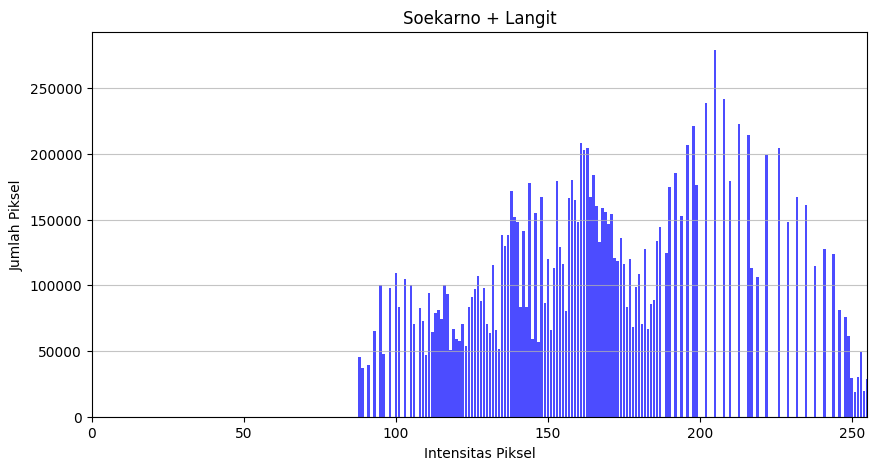

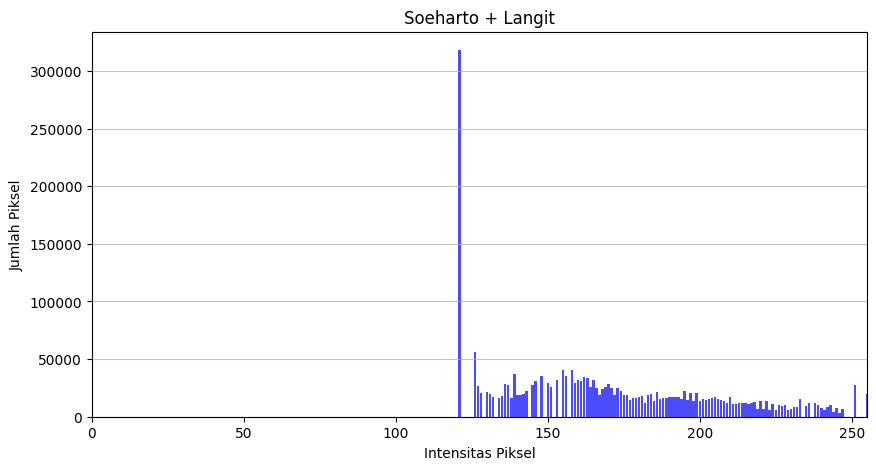

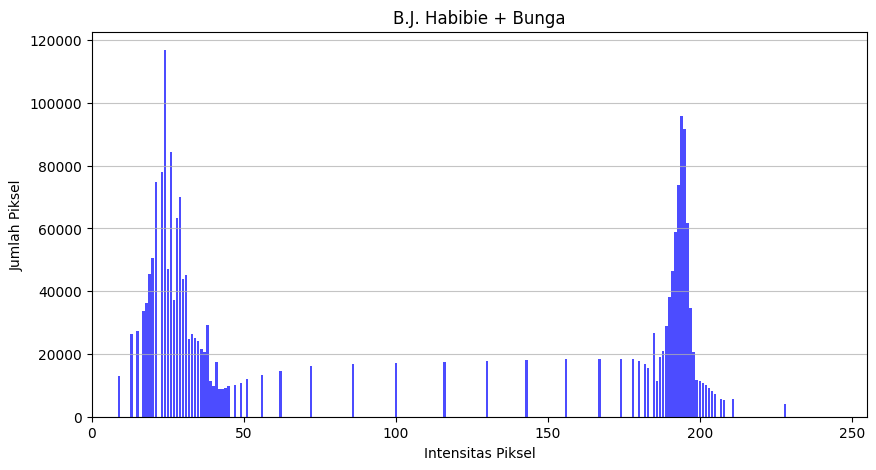

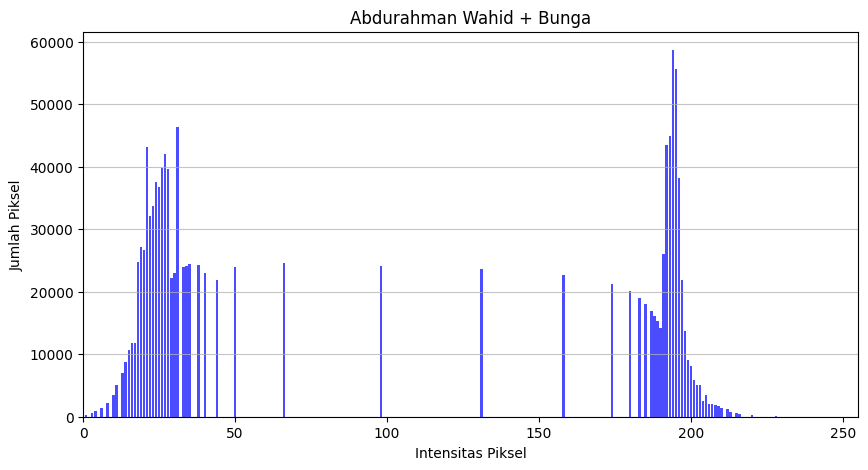

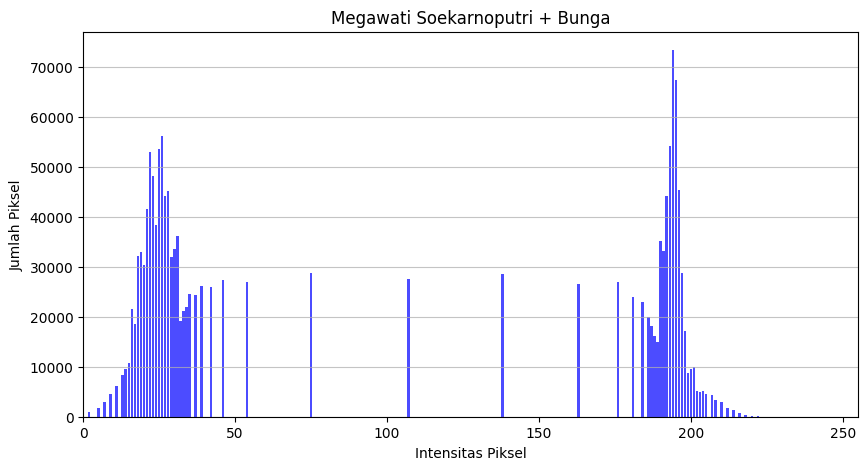

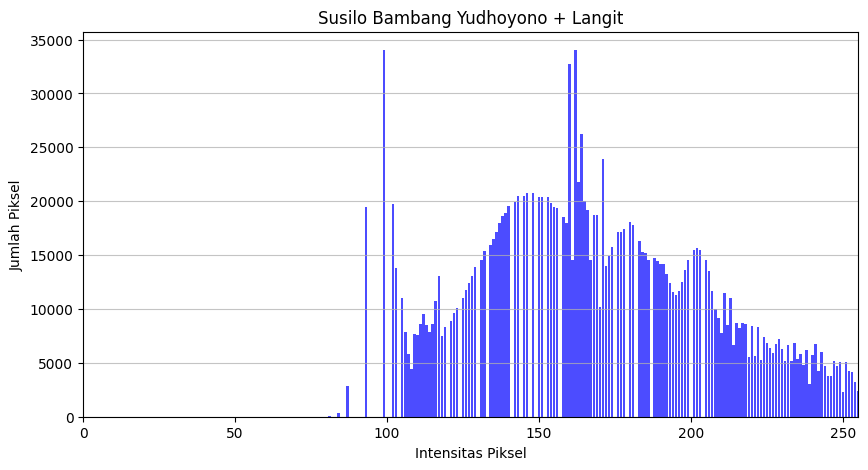

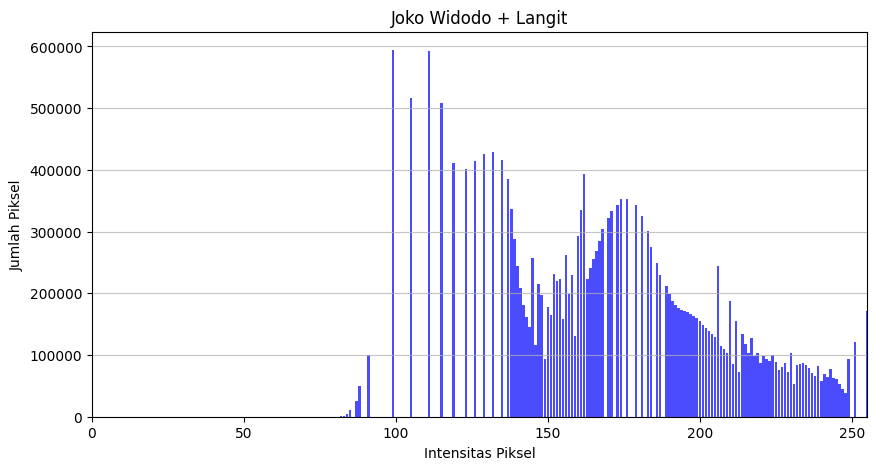

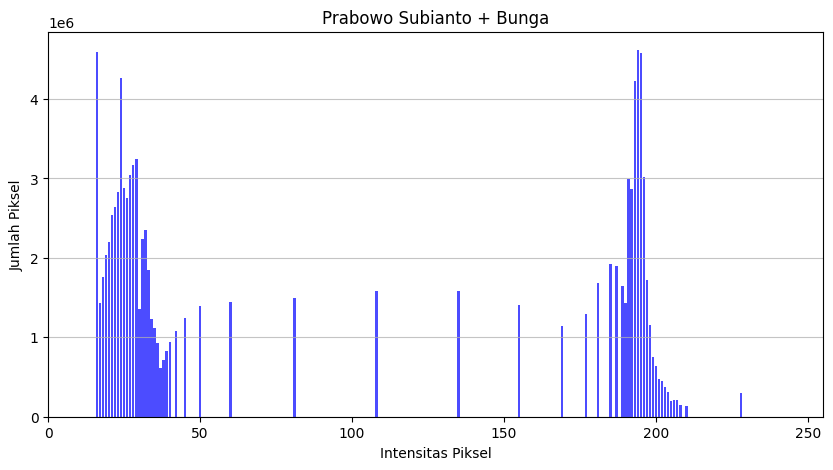

In [14]:
for data in dataset:

    plot_histogram(
        buat_hist(data['spesifikasi']),
        f"{data['nama']} + {data['target']}"
    )